In [2]:
import pandas as pd

df = pd.read_csv("jobs.csv")
df

,job_title,skills
0,Data Scientist,python pandas numpy machine learning statistics
1,Web Developer,html css javascript react nodejs
2,Backend Developer,python flask api sql database
3,AI Engineer,python machine learning deep learning tensorfl...
4,Mobile App Developer,java kotlin android ui ux
5,DevOps Engineer,docker kubernetes aws ci cd linux


In [3]:
def recommend_jobs(user_skills):
    user_skills = set(user_skills.lower().split(","))
    results = []

    for _, row in df.iterrows():
        job_skills = set(row["skills"].split(","))
        
        match_score = len(user_skills & job_skills)
        missing_skills = job_skills - user_skills
        
        results.append({
            "job": row["job_title"],
            "match_score": match_score,
            "missing_skills": list(missing_skills)
        })
    
    return sorted(results, key=lambda x: x["match_score"], reverse=True)

In [5]:
user_input = input("Enter your skills (comma separated): ")
recommendations = recommend_jobs(user_input)

recommendations

Enter your skills (comma separated):  data scientist, java, kotlin, mobile app developer


[{'job': 'Data Scientist',
  'match_score': 0,
  'missing_skills': ['python pandas numpy machine learning statistics']},
 {'job': 'Web Developer',
  'match_score': 0,
  'missing_skills': ['html css javascript react nodejs']},
 {'job': 'Backend Developer',
  'match_score': 0,
  'missing_skills': ['python flask api sql database']},
 {'job': 'AI Engineer',
  'match_score': 0,
  'missing_skills': ['python machine learning deep learning tensorflow pytorch']},
 {'job': 'Mobile App Developer',
  'match_score': 0,
  'missing_skills': ['java kotlin android ui ux']},
 {'job': 'DevOps Engineer',
  'match_score': 0,
  'missing_skills': ['docker kubernetes aws ci cd linux']}]

In [ ]:
for r in recommendations:
    print(f"\n🔹 Job: {r['job']}")
    print(f"Match Score: {r['match_score']}")
    print(f"Missing Skills: {r['missing_skills']}")

In [ ]:
import matplotlib.pyplot as plt

jobs = [r["job"] for r in recommendations]
scores = [r["match_score"] for r in recommendations]

plt.bar(jobs, scores)
plt.title("Job Match Scores")
plt.xticks(rotation=30)
plt.show()

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def recommend_jobs_advanced(user_input):
    corpus = df["skills"].tolist()
    
    vectorizer = TfidfVectorizer()
    vectors = vectorizer.fit_transform(corpus + [user_input])
    
    similarity = cosine_similarity(vectors[-1], vectors[:-1])
    
    scores = similarity.flatten()
    
    results = []
    for i, score in enumerate(scores):
        results.append({
            "job": df.iloc[i]["job_title"],
            "score": score
        })
    
    return sorted(results, key=lambda x: x["score"], reverse=True)

In [7]:
user_input = input("Enter your skills: ")
recommend_jobs_advanced(user_input)

Enter your skills:  python, flask


[{'job': 'Backend Developer', 'score': np.float64(0.5124759281221005)},
 {'job': 'Data Scientist', 'score': np.float64(0.1683079330785824)},
 {'job': 'AI Engineer', 'score': np.float64(0.14052558501766343)},
 {'job': 'Web Developer', 'score': np.float64(0.0)},
 {'job': 'Mobile App Developer', 'score': np.float64(0.0)},
 {'job': 'DevOps Engineer', 'score': np.float64(0.0)}]

In [8]:
results = recommend_jobs_advanced(user_input)

for r in results[:3]:
    print(f"\n🚀 Job: {r['job']}")
    print(f"Match Score: {round(r['score']*100, 2)}%")


🚀 Job: Backend Developer
Match Score: 51.25%

🚀 Job: Data Scientist
Match Score: 16.83%

🚀 Job: AI Engineer
Match Score: 14.05%


In [9]:
def skill_gap(user_input):
    user_skills = set(user_input.lower().split())
    
    for _, row in df.iterrows():
        job_skills = set(row["skills"].split())
        missing = job_skills - user_skills
        
        print(f"\n📌 {row['job_title']}")
        print(f"Missing Skills: {list(missing)}")

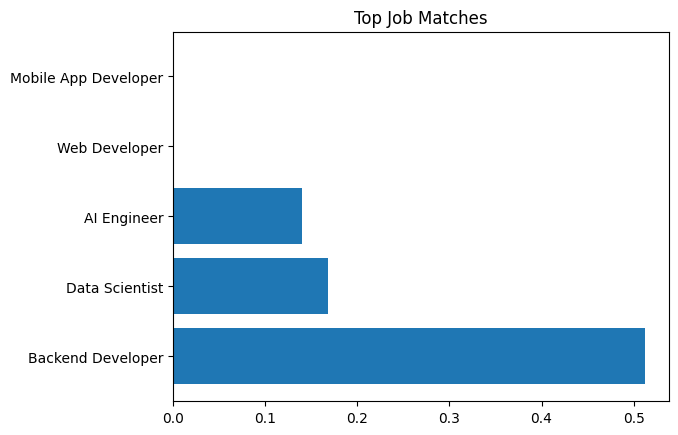

In [10]:
import matplotlib.pyplot as plt

jobs = [r["job"] for r in results[:5]]
scores = [r["score"] for r in results[:5]]

plt.barh(jobs, scores)
plt.title("Top Job Matches")
plt.show()

In [11]:
resources = {
    "python": "https://youtube.com/results?search_query=learn+python",
    "machine": "https://youtube.com/results?search_query=machine+learning",
    "react": "https://youtube.com/results?search_query=react+js",
    "docker": "https://youtube.com/results?search_query=docker+tutorial"
}

def suggest_resources(missing_skills):
    for skill in missing_skills:
        if skill in resources:
            print(f"{skill}: {resources[skill]}")